# Set-Up

In [ ]:
# Imports for Generating & Viewing Data #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed

In [2]:
# Constants #

IMAGE_X = 256
IMAGE_Y = 256

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

SCALE_FACTOR = 8

LABEL_X = IMAGE_X // SCALE_FACTOR
LABEL_Y = IMAGE_Y // SCALE_FACTOR

MIN_NUM_GAUSSIANS = 2
MAX_NUM_GAUSSIANS = 5

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

THRESHOLD = 0.9

SOFT_LABEL_SIGMA = 0.75

SEED = 0
rng = np.random.default_rng(SEED)

In [3]:
# Utility Functions for Generating Data #

# TODO: consider param array
def gen_data(num_images: int) -> tuple:

    img_arr = np.empty((num_images, IMAGE_Y, IMAGE_X, 1), dtype=np.float32)
    label_arr = np.empty((num_images, LABEL_Y, LABEL_X, 1), dtype=np.float32)

    for i in tqdm(range(num_images)):
        img, label, _ = img_gen()
        img_arr[i] = img.astype(np.float32) / 256.0  # Normalize values to [0, 1)
        label_arr[i] = label.astype(np.float32) / 256.0  # Normalize values to [0, 1)

    print(f"[Images Shape]: {img_arr.shape}")
    print(f"[Labels Shape]: {label_arr.shape}")

    return (img_arr, label_arr)


def img_gen() -> tuple:

    img = np.zeros(shape=(IMAGE_Y, IMAGE_X, 1))
    params = []

    num_gaussians = rng.integers(low=MIN_NUM_GAUSSIANS, high=MAX_NUM_GAUSSIANS + 1)
    for _ in range(num_gaussians):
        # Randomize params
        center_x = rng.integers(low=0 + GAUSSIAN_X // 2, high=IMAGE_X - GAUSSIAN_X // 2)
        center_y = rng.integers(low=0 + GAUSSIAN_Y // 2, high=IMAGE_Y - GAUSSIAN_Y // 2)

        std_x = rng.uniform(MIN_STD_X, MAX_STD_X)
        std_y = rng.uniform(MIN_STD_Y, MAX_STD_Y)
        theta = rng.uniform(MIN_THETA, MAX_THETA)

        intensity = MIN_INTENSITY + rng.random() * (MAX_INTENSITY - MIN_INTENSITY)

        # Generate Gaussian
        params.append((center_x, center_y, std_x, std_y, theta, intensity))
        gaussian = np.array(gaussian_gen(center_x, center_y, std_x, std_y, theta))

        # Add Gaussian to img
        img += gaussian * intensity

    # Apply gaussian labelling
    label = make_soft_label(params, LABEL_Y, LABEL_X, SCALE_FACTOR)

    # Convert to 8 bit int
    label = (label * 255).astype(np.uint8)
    img = (np.clip(img, 0.0, 1.0) * 255).astype(np.uint8)

    return (img, label, params)


X, Y = np.meshgrid(np.arange(IMAGE_X), np.arange(IMAGE_Y))


def gaussian_gen(
    center_x: float, center_y: float, std_x: float, std_y: float, theta: float, X=X, Y=Y
) -> np.ndarray:

    cos_theta_sqrd = np.power(np.cos(theta), 2)
    sin_theta_sqrd = np.power(np.sin(theta), 2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.power(std_x, 2)
    std_y_sqrd = np.power(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(
        -(
            a * (X - center_x) ** 2
            + 2 * b * (X - center_x) * (Y - center_y)
            + c * (Y - center_y) ** 2
        )
    )

    return np.expand_dims(gaussian, -1)


def make_soft_label(
    params, label_h, label_w, scale_factor, sigma=SOFT_LABEL_SIGMA
) -> np.ndarray:

    yy, xx = np.meshgrid(np.arange(label_h), np.arange(label_w), indexing="ij")
    label = np.zeros((label_h, label_w), dtype=np.float32)

    for center_x, center_y, std_x, std_y, theta, intensity in params:
        gx = center_x / scale_factor
        gy = center_y / scale_factor

        bump = np.exp(-((xx - gx) ** 2 + (yy - gy) ** 2) / (2 * sigma**2))
        label = np.maximum(label, bump)

    return label[..., None]

# Train / Load Qkeras Model

In [4]:
# Imports for Training #

import tensorflow as tf
import keras.backend as K
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Add, Activation
from tensorflow.keras.activations import relu, sigmoid
from tensorflow.keras.models import Model
from qkeras import QConv2D, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu

2026-05-04 02:08:26.059790: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 02:08:26.060796: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-04 02:08:26.075001: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-04 02:08:26.075015: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-04 02:08:26.075025: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

In [5]:
# Create TF Datasets #
# TODO: look into using tf.data.Dataset.from_generator
# TODO: look into parallelizing
TRAINING_DATASET_SIZE = 10000
VALIDATION_DATASET_SIZE = 1000
TEST_DATASET_SIZE = 1000
BATCH_SIZE = 50


train_img_arr, train_label_arr = gen_data(TRAINING_DATASET_SIZE)
val_img_arr, val_label_arr = gen_data(VALIDATION_DATASET_SIZE)
test_img_arr, test_label_arr = gen_data(TEST_DATASET_SIZE)

train_dataset = (
    tf.data.Dataset.from_tensor_slices((train_img_arr, train_label_arr))
    .shuffle(TRAINING_DATASET_SIZE, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((val_img_arr, val_label_arr))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

100%|██████████| 10000/10000 [00:09<00:00, 1101.58it/s]


[Images Shape]: (10000, 256, 256, 1)
[Labels Shape]: (10000, 32, 32, 1)


100%|██████████| 1000/1000 [00:00<00:00, 1105.45it/s]


[Images Shape]: (1000, 256, 256, 1)
[Labels Shape]: (1000, 32, 32, 1)


100%|██████████| 1000/1000 [00:00<00:00, 1084.19it/s]
2026-05-04 02:08:37.822354: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error


[Images Shape]: (1000, 256, 256, 1)
[Labels Shape]: (1000, 32, 32, 1)


2026-05-04 02:08:37.822367: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: uw-acme
2026-05-04 02:08:37.822369: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: uw-acme
2026-05-04 02:08:37.822414: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: 580.126.9
2026-05-04 02:08:37.822421: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: NOT_FOUND: could not find kernel module information in driver version file contents: "NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  580.126.09  Release Build  (dvs-builder@U22-I3-AM02-24-3)  Wed Jan  7 22:51:36 UTC 2026
GCC version:  gcc version 12.3.0 (Ubuntu 12.3.0-1ubuntu1~22.04.3) 
"


In [6]:
# Qkeras Model Architecture #
TOTAL_BITS = 8
INTEGER_BITS = 0


w_quant = quantized_bits(
    TOTAL_BITS, INTEGER_BITS, symmetric=False, keep_negative=True, alpha=1
)
relu_quant = quantized_relu(TOTAL_BITS, INTEGER_BITS)

input_layer = Input(shape=(IMAGE_Y, IMAGE_X, 1))

x = QConv2D(
    filters=4,
    kernel_size=3,
    strides=2,
    padding="same",
    use_bias=False,
    name="qconv2d_1_1",
    kernel_quantizer=w_quant,
    kernel_initializer="lecun_uniform",
)(input_layer)
# x = BatchNormalization(name="b_1_1")(x)
x = QActivation(relu_quant, name="qact_1_1")(x)
y = QConv2D(
    filters=4,
    kernel_size=3,
    padding="same",
    use_bias=False,
    name="qconv2d_1_2",
    kernel_quantizer=w_quant,
    kernel_initializer="lecun_uniform",
)(x)
# y = BatchNormalization(name="b_1_2")(y)
x = Add(name="add_1")([x, y])
x = QActivation(relu_quant, name="qact_1_2")(x)

x = QConv2D(
    filters=6,
    kernel_size=3,
    strides=2,
    padding="same",
    use_bias=False,
    name="qconv2d_2_1",
    kernel_quantizer=w_quant,
    kernel_initializer="lecun_uniform",
)(x)
# x = BatchNormalization(name="b_2_1")(x)
x = QActivation(relu_quant, name="qact_2_1")(x)
y = QConv2D(
    filters=6,
    kernel_size=3,
    padding="same",
    use_bias=False,
    name="qconv2d_2_2",
    kernel_quantizer=w_quant,
    kernel_initializer="lecun_uniform",
)(x)
# y = BatchNormalization(name="b_2_2")(y)
x = Add(name="add_2")([x, y])
x = QActivation(relu_quant, name="qact_2_2")(x)

x = QConv2D(
    filters=8,
    kernel_size=3,
    strides=2,
    padding="same",
    use_bias=False,
    name="qconv2d_3_1",
    kernel_quantizer=w_quant,
    kernel_initializer="lecun_uniform",
)(x)
# x = BatchNormalization(name="b_3_1")(x)
x = QActivation(relu_quant, name="qact_3_1")(x)
y = QConv2D(
    filters=8,
    kernel_size=3,
    padding="same",
    use_bias=False,
    name="qconv2d_3_2",
    kernel_quantizer=w_quant,
    kernel_initializer="lecun_uniform",
)(x)
# y = BatchNormalization(name="b_3_2")(y)
x = Add(name="add_3")([x, y])
x = QActivation(relu_quant, name="qact_3_2")(x)

x = Conv2D(8, 1, padding="same", use_bias=True, name="qconv2d_4")(x)
x = Activation(relu, name="qact_4")(x)

x = Conv2D(1, 1, padding="same", use_bias=True, name="qconv2d_5")(x)
x_prob = Activation(sigmoid, name="sigmoid_out")(x)

baby_yolo_qk = Model(inputs=input_layer, outputs=x_prob, name="baby_yolo")

In [7]:
# Tensorflow Functions #
POS_WEIGHT = 5.0
NEG_WEIGHT = 1.0


def loss_wbce(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)

    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

    bce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
    weights = y_true * POS_WEIGHT + (1.0 - y_true) * NEG_WEIGHT

    return tf.reduce_mean(weights * bce)

In [8]:
# Train or Load #
# TODO: Fix Load
TRAIN_MODEL = True
LOAD_MODEL = False

NUM_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10
MIN_DELTA = 1e-4


if TRAIN_MODEL and LOAD_MODEL:
    print("Are you sure you want to Train & Load ?")

elif TRAIN_MODEL:
    adam_optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-3,
        global_clipnorm=1.0,
    )

    baby_yolo_qk.compile(
        optimizer=adam_optimizer,
        loss=loss_wbce,
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1,
    )

    history = baby_yolo_qk.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=NUM_EPOCHS,
        callbacks=[early_stop, reduce_lr],
        verbose=1,
    )

elif LOAD_MODEL:
    pass
    # from qkeras.utils import _add_supported_quantized_objects
    # co = {}
    # _add_supported_quantized_objects(co)
    # co['loss_wbce'] = loss_wbce
    # baby_yolo_qk = tf.keras.models.load_model(f'../Models/{MODEL_NAME}', custom_objects=co)

baby_yolo_qk.summary()

Epoch 1/100
200/200 [==============================] - 5s 25ms/step - loss: 0.4945 - val_loss: 0.3021 - lr: 0.0010
Epoch 2/100
200/200 [==============================] - 5s 24ms/step - loss: 0.2056 - val_loss: 0.1377 - lr: 0.0010
Epoch 3/100
200/200 [==============================] - 5s 24ms/step - loss: 0.1068 - val_loss: 0.0849 - lr: 0.0010
Epoch 4/100
200/200 [==============================] - 5s 24ms/step - loss: 0.0741 - val_loss: 0.0657 - lr: 0.0010
Epoch 5/100
200/200 [==============================] - 5s 24ms/step - loss: 0.0613 - val_loss: 0.0574 - lr: 0.0010
Epoch 6/100
200/200 [==============================] - 5s 24ms/step - loss: 0.0552 - val_loss: 0.0529 - lr: 0.0010
Epoch 7/100
200/200 [==============================] - 5s 24ms/step - loss: 0.0519 - val_loss: 0.0505 - lr: 0.0010
Epoch 8/100
200/200 [==============================] - 5s 24ms/step - loss: 0.0500 - val_loss: 0.0488 - lr: 0.0010
Epoch 9/100
200/200 [==============================] - 5s 24ms/step - loss: 0.04

# Test QKeras Model

In [9]:
# Utility Functions for Viewing Data #
# TODO: add comparison functions

In [10]:
# Predict on Test Set #

predictions_qk = baby_yolo_qk.predict(test_img_arr)

print(f"[Test Shape]: {test_label_arr.shape}")
print(f"[Prediction Shape]: {predictions_qk.shape}")

32/32 [==============================] - 0s 8ms/step
[Test Shape]: (1000, 32, 32, 1)
[Prediction Shape]: (1000, 32, 32, 1)


In [11]:
# Emperically Compare Performance #
# TODO: consider better metrics

# Mean Squared Error
mse = np.mean((test_label_arr - predictions_qk) ** 2)

# Mean Absolute Error
mae = np.mean(np.abs(test_label_arr - predictions_qk))

print("MSE:", mse)
print("MAE:", mae)

MSE: 0.00018626377
MAE: 0.0021333594


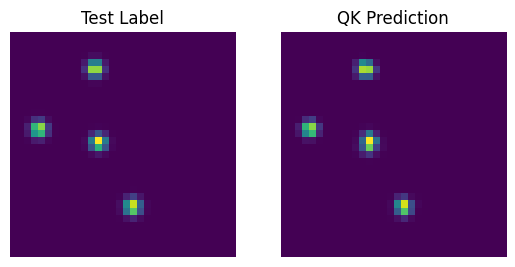

In [15]:
# Visually Compare Predictions #
index = np.random.randint(low=0, high=TEST_DATASET_SIZE)

fig, axes = plt.subplots(1, 2)
im0 = axes[0].imshow(test_label_arr[index], cmap="viridis", interpolation="none")
axes[0].set_title("Test Label")
axes[0].axis("off")

im1 = axes[1].imshow(predictions_qk[index], cmap="viridis", interpolation="none")
axes[1].set_title("QK Prediction")
axes[1].axis("off")

plt.show()

In [21]:
# Save Model #
SAVE_MODEL = False
MODEL_NAME = "[FOLO]_[Generated]_[256]_Q.keras"

if SAVE_MODEL:
    baby_yolo_qk.save(f"Models/{MODEL_NAME}")

# Convert to HLS

In [22]:
# Imports for HLS #

import hls4ml
from hls4ml.utils import config_from_keras_model
from pprint import pprint

In [23]:
# HLS4ML Config #
# TODO: look into pipeline

config = config_from_keras_model(baby_yolo_qk, granularity="name", backend="Vitis")

# Fifo Depth Optimization (greatly reduces BRAM)
config["Flows"] = ["vitis:fifo_depth_optimization"]
hls4ml.model.optimizer.get_optimizer("vitis:fifo_depth_optimization").configure(
    profiling_fifo_depth=100_000
)

# Strategy
config["Model"]["Strategy"] = "Latency"
# config['Model']['PipelineStyle'] = 'pipeline'

# Reuse Factor
config["Model"]["ReuseFactor"] = 8
for layer_cfg in config["LayerName"].values():
    if "ReuseFactor" in layer_cfg:
        layer_cfg["ReuseFactor"] = 8

# Ensure Proper Quantization
for layer in config["LayerName"]:
    if layer.startswith("conv2d") and layer not in ["conv2d_4", "conv2d_5"]:  # QConv2D
        precision = config["LayerName"][layer].get("Precision", {})
        for key in precision:
            if precision[key] == "auto":
                precision[key] = "fixed<8,0>"
    if layer.startswith("act_"):  # QActivation
        config["LayerName"][layer]["Precision"]["result"] = "fixed<8,0>"

pprint(config)

{'Flows': ['vitis:fifo_depth_optimization'],
 'LayerName': {'add_1': {'Precision': {'result': 'auto'},
                         'ReuseFactor': 8,
                         'Trace': False},
               'add_2': {'Precision': {'result': 'auto'},
                         'ReuseFactor': 8,
                         'Trace': False},
               'add_3': {'Precision': {'result': 'auto'},
                         'ReuseFactor': 8,
                         'Trace': False},
               'input_1': {'Precision': {'result': 'auto'}, 'Trace': False},
               'qact_1_1': {'Precision': {'result': 'ufixed<8,0,RND_CONV,SAT,0>',
                                          'table': 'fixed<18,8,TRN,WRAP,0>'},
                            'ReuseFactor': 8,
                            'TableSize': 1024,
                            'Trace': False},
               'qact_1_2': {'Precision': {'result': 'ufixed<8,0,RND_CONV,SAT,0>',
                                          'table': 'fixed<18,8,TRN,WR

/home/pujan/Research/Rheed-Folo/.venv/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [ ]:
# Compile & Predict #
# Make sure you copy over the TB Data found in Utils

hls_model = hls4ml.converters.convert_from_keras_model(
    baby_yolo_qk,
    hls_config=config,
    output_dir="../folo_hls4ml_Q",
    io_type="io_stream",  # io_parallel
    backend="Vitis",
    part="xcku035-fbva676-2-e",
    project_name="folo",
)

hls_model.compile()

predictions_hls4ml = hls_model.predict(test_img_arr).reshape(
    TEST_DATASET_SIZE, LABEL_Y, LABEL_X
)

print(f"[Test Shape]: {test_label_arr.shape}")
print(f"[Prediction Shape]: {predictions_hls4ml.shape}")

In [ ]:
# Build Model #
# vitis_hls build_prj.tcl
# vitis-run --mode hls --tcl build_prj.tcl

# hls_model.build()

In [ ]:
# View Report #

hls4ml.report.read_vivado_report("folo_hls4ml_Q")